In [1]:
!pip install konlpy
!apt-get install -y openjdk-11-jdk
!apt-get install -y fonts-nanum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 87.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 38.1 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-dejavu-core fonts-dejavu-extra libatk-wrapper-java
  libatk-wrapper-java-jni libxt-dev libxtst6 libxxf86dga1 openjdk-11-jre
  x11-utils
Suggested packages:
  libxt-doc openjdk-11-demo openjdk-11-source visualvm mesa-utils
The following NEW packages will be installed:
  fonts-dejavu-core fonts-dejavu-extra libatk-wrapper-java
  libatk-wrapper-java-jni libxt-dev libxtst6 libxxf86dga1 openjdk-11-jdk
  openjdk-11-jre x11-utils
0 upgraded, 10 newly installed, 0 to remove and 35 not upgraded.
Need to get 5,367 kB of archives.
After this operation, 15.2 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-dejavu-core all 2.37-2bui

In [2]:
!fc-list | grep Nanum


/usr/share/fonts/truetype/nanum/NanumSquareRoundB.ttf: NanumSquareRound,나눔스퀘어라운드,NanumSquareRound Bold,나눔스퀘어라운드 Bold:style=Bold,Regular
/usr/share/fonts/truetype/nanum/NanumGothicCodingBold.ttf: NanumGothicCoding,나눔고딕코딩:style=Bold
/usr/share/fonts/truetype/nanum/NanumSquareRoundR.ttf: NanumSquareRound,나눔스퀘어라운드,NanumSquareRound Regular,나눔스퀘어라운드 Regular:style=Regular
/usr/share/fonts/truetype/nanum/NanumSquareB.ttf: NanumSquare,나눔스퀘어,NanumSquare Bold,나눔스퀘어 Bold:style=Bold
/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf: NanumBarunGothic,나눔바른고딕:style=Regular
/usr/share/fonts/truetype/nanum/NanumGothic.ttf: NanumGothic,나눔고딕:style=Regular
/usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf: NanumGothicCoding,나눔고딕코딩:style=Regular
/usr/share/fonts/truetype/nanum/NanumBarunGothicBold.ttf: NanumBarunGothic,나눔바른고딕:style=Bold
/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf: NanumGothic,나눔고딕:style=Bold
/usr/share/fonts/truetype/nanum/NanumSquareR.ttf: NanumSquare,나눔스퀘어:style=Regular
/us

In [3]:
import pandas as pd

DATA_PATH = "/content/ratings_test.txt"

df = pd.read_csv(DATA_PATH, sep="\t")

print(df.shape)
print(df.head())



(50000, 3)
        id                                           document  label
0  6270596                                                굳 ㅋ      1
1  9274899                               GDNTOPCLASSINTHECLUB      0
2  8544678             뭐야 이 평점들은.... 나쁘진 않지만 10점 짜리는 더더욱 아니잖아      0
3  6825595                   지루하지는 않은데 완전 막장임... 돈주고 보기에는....      0
4  6723715  3D만 아니었어도 별 다섯 개 줬을텐데.. 왜 3D로 나와서 제 심기를 불편하게 하죠??      0


In [4]:
import re

def clean_text(text):
    text = str(text)
    text = re.sub(r"[^ㄱ-ㅎㅏ-ㅣ가-힣 ]", "", text)
    return text.strip()

df["clean_review"] = df["document"].apply(clean_text)
print(df[["document", "clean_review"]].head())

                                            document  \
0                                                굳 ㅋ   
1                               GDNTOPCLASSINTHECLUB   
2             뭐야 이 평점들은.... 나쁘진 않지만 10점 짜리는 더더욱 아니잖아   
3                   지루하지는 않은데 완전 막장임... 돈주고 보기에는....   
4  3D만 아니었어도 별 다섯 개 줬을텐데.. 왜 3D로 나와서 제 심기를 불편하게 하죠??   

                                clean_review  
0                                        굳 ㅋ  
1                                             
2           뭐야 이 평점들은 나쁘진 않지만 점 짜리는 더더욱 아니잖아  
3                  지루하지는 않은데 완전 막장임 돈주고 보기에는  
4  만 아니었어도 별 다섯 개 줬을텐데 왜 로 나와서 제 심기를 불편하게 하죠  


In [5]:
from konlpy.tag import Okt
okt = Okt()

def tokenize(text):
    return [word for word in okt.nouns(text) if len(word) > 1]

df["tokens"] = df["clean_review"].apply(tokenize)
print(df[["clean_review", "tokens"]].head())

                                clean_review        tokens
0                                        굳 ㅋ            []
1                                                       []
2           뭐야 이 평점들은 나쁘진 않지만 점 짜리는 더더욱 아니잖아      [평점, 더욱]
3                  지루하지는 않은데 완전 막장임 돈주고 보기에는  [완전, 막장, 보기]
4  만 아니었어도 별 다섯 개 줬을텐데 왜 로 나와서 제 심기를 불편하게 하죠      [다섯, 심기]


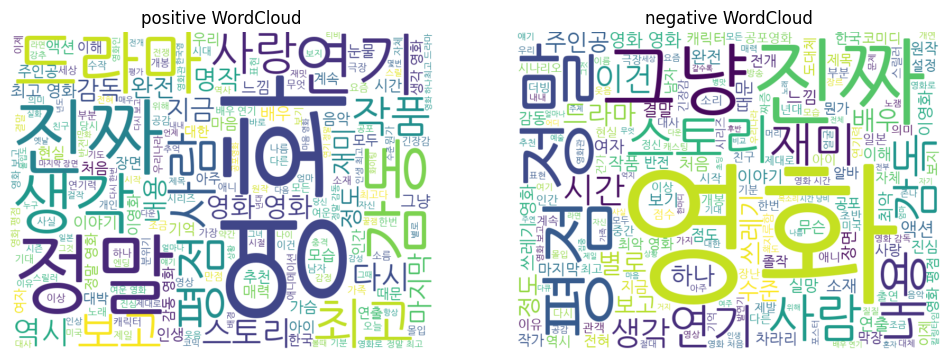

In [6]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_words = df[df["label"] == 1]["tokens"].sum()
positive_text = " ".join(positive_words)

negative_words = df[df["label"] == 0]["tokens"].sum()
negative_text = " ".join(negative_words)

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

wordcloud_pos = WordCloud(font_path=font_path,
                          background_color="white",
                          width=800, height=600).generate(positive_text)

wordcloud_neg = WordCloud(font_path=font_path,
                          background_color="white",
                          width=800, height=600).generate(negative_text)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(wordcloud_pos, interpolation="bilinear")
plt.title("positive WordCloud")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(wordcloud_neg, interpolation="bilinear")
plt.title("negative WordCloud")
plt.axis("off")

plt.show()

In [14]:
sample_reviews = df[df["clean_review"].str.strip() != ""]
sample_reviews = sample_reviews[["clean_review", "label"]].dropna().head(10)
with open("/content/sentiment_results.txt", "w", encoding="utf-8") as f:
    for idx, row in enumerate(sample_reviews.itertuples(), start=1):
        label = "긍정" if row.label == 1 else "부정"
        f.write(f"{idx}. [{label}] {row.clean_review}\n")
